# Preventive Healthcare Risk Prediction
## Diabetes Classification Across PIMA and NHANES

## Project Objective
Evaluate how Logistic Regression and Random Forest perform across two diabetes datasets with different class distributions, with particular attention to recall, ROC-AUC, F1 score, and the limitations of accuracy under class imbalance.

## Data Sources
- **PIMA:** Diabetes dataset used for comparative predictive modelling.
- **NHANES:** Public health survey data used for population-level diabetes classification analysis.

## Tools
Python · Pandas · NumPy · Scikit-learn · Matplotlib · Google Colab

> Raw and participant-level datasets are not included in this repository.


In [ ]:
# SECTION 1 — SETUP & DATA LOADING
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
from pathlib import Path

# Resolve project folders whether the notebook is opened
# from the repository root or from /notebooks
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

PIMA_ZIP = DATA_DIR / "PIMA.zip"
NHANES_ZIP = DATA_DIR / "NHANES.zip"

# Raw datasets are intentionally excluded from this public repository.
# Place the source ZIP files inside data/raw/ before running the notebook.
if not PIMA_ZIP.exists() or not NHANES_ZIP.exists():
    raise FileNotFoundError(
        "Required source datasets were not found. "
        "Place PIMA.zip and NHANES.zip inside data/raw/."
    )

PIMA_DIR = DATA_DIR / "pima_data"
NHANES_DIR = DATA_DIR / "nhanes_data"

PIMA_DIR.mkdir(exist_ok=True)
NHANES_DIR.mkdir(exist_ok=True)

with zipfile.ZipFile(PIMA_ZIP) as z:
    z.extractall(PIMA_DIR)

with zipfile.ZipFile(NHANES_ZIP) as z:
    z.extractall(NHANES_DIR)

print("Setup complete. Source datasets loaded locally.")


In [ ]:
# SECTION 2 — DATA CLEANING

# PIMA
pima = pd.read_csv(PIMA_DIR / 'diabetes.csv')

# Impossible zeros are disguised missing values -> NaN
zero_as_missing = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
pima[zero_as_missing] = pima[zero_as_missing].replace(0, np.nan)

# Impute with group-wise median by Outcome (preserves diabetic/non-diabetic difference)
for col in zero_as_missing:
    pima[col] = pima.groupby('Outcome')[col].transform(lambda s: s.fillna(s.median()))

print("PIMA cleaned:", pima.shape, "| missing left:", int(pima.isna().sum().sum()))

# NHANES
nd = NHANES_DIR
demo = pd.read_csv(nd / 'demographic.csv',  usecols=lambda c: c in ['SEQN','RIDAGEYR','RIAGENDR','RIDRETH1','INDFMPIR'])
exam = pd.read_csv(nd / 'examination.csv',  usecols=lambda c: c in ['SEQN','BMXBMI','BMXWAIST','BPXSY1'])
labs = pd.read_csv(nd / 'labs.csv',         usecols=lambda c: c in ['SEQN','LBXGH'])

# Merge the three files on participant ID
nhanes = demo.merge(exam, on='SEQN', how='inner').merge(labs, on='SEQN', how='inner')

# Target requires HbA1c; drop rows without it
before = len(nhanes)
nhanes = nhanes.dropna(subset=['LBXGH'])
print(f"NHANES: dropped {before - len(nhanes)} rows without HbA1c. Remaining: {len(nhanes)}")

# Outcome: diabetic if HbA1c >= 6.5%
nhanes['Diabetes'] = (nhanes['LBXGH'] >= 6.5).astype(int)

# Readable column names
nhanes = nhanes.rename(columns={
    'RIDAGEYR':'Age','RIAGENDR':'Sex','RIDRETH1':'Ethnicity','INDFMPIR':'IncomeRatio',
    'BMXBMI':'BMI','BMXWAIST':'Waist','BPXSY1':'SystolicBP','LBXGH':'HbA1c'})
nhanes['Sex'] = nhanes['Sex'].map({1:'Male', 2:'Female'})

# Median-impute remaining numeric predictors
for c in ['Age','BMI','Waist','SystolicBP','IncomeRatio']:
    if c in nhanes: nhanes[c] = nhanes[c].fillna(nhanes[c].median())

nhanes = nhanes.drop_duplicates(subset='SEQN')
nhanes = nhanes.drop(columns=['SEQN'], errors='ignore')
print("NHANES cleaned:", nhanes.shape)

# PRIVACY NOTE
# Cleaned participant-level datasets remain in memory only.
# They are intentionally not exported or included in this repository.

print("Data preparation complete. Participant-level data retained in memory only.")


In [ ]:
# SECTION 3 — CLASS BALANCE CHECK
# Justifies why accuracy is insufficient and class weighting is needed

print("PIMA (Outcome):",   pima['Outcome'].value_counts().to_dict(),
      "| ratio:", pima['Outcome'].value_counts(normalize=True).round(3).to_dict())

print("NHANES (Diabetes):", nhanes['Diabetes'].value_counts().to_dict(),
      "| ratio:", nhanes['Diabetes'].value_counts(normalize=True).round(3).to_dict())

PIMA (Outcome): {0: 500, 1: 268} | ratio: {0: 0.651, 1: 0.349}
NHANES (Diabetes): {0: 6039, 1: 604} | ratio: {0: 0.909, 1: 0.091}


  PIMA  (n=768, positives=268)

--- Logistic Regression ---
ROC-AUC: 0.827
Confusion matrix [[TN FP][FN TP]]:
[[73 27]
 [12 42]]
              precision    recall  f1-score   support

           0      0.859     0.730     0.789       100
           1      0.609     0.778     0.683        54

    accuracy                          0.747       154
   macro avg      0.734     0.754     0.736       154
weighted avg      0.771     0.747     0.752       154


--- Random Forest ---
ROC-AUC: 0.947
Confusion matrix [[TN FP][FN TP]]:
[[91  9]
 [12 42]]
              precision    recall  f1-score   support

           0      0.883     0.910     0.897       100
           1      0.824     0.778     0.800        54

    accuracy                          0.864       154
   macro avg      0.854     0.844     0.848       154
weighted avg      0.862     0.864     0.863       154



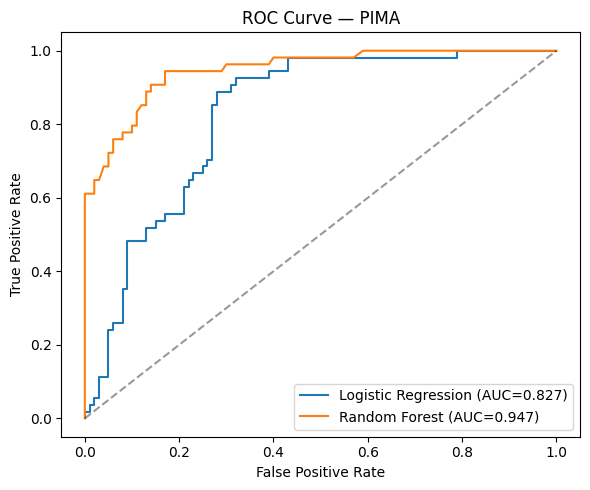

  NHANES  (n=6643, positives=604)

--- Logistic Regression ---
ROC-AUC: 0.818
Confusion matrix [[TN FP][FN TP]]:
[[877 331]
 [ 30  91]]
              precision    recall  f1-score   support

           0      0.967     0.726     0.829      1208
           1      0.216     0.752     0.335       121

    accuracy                          0.728      1329
   macro avg      0.591     0.739     0.582      1329
weighted avg      0.899     0.728     0.784      1329


--- Random Forest ---
ROC-AUC: 0.803
Confusion matrix [[TN FP][FN TP]]:
[[1203    5]
 [ 118    3]]
              precision    recall  f1-score   support

           0      0.911     0.996     0.951      1208
           1      0.375     0.025     0.047       121

    accuracy                          0.907      1329
   macro avg      0.643     0.510     0.499      1329
weighted avg      0.862     0.907     0.869      1329



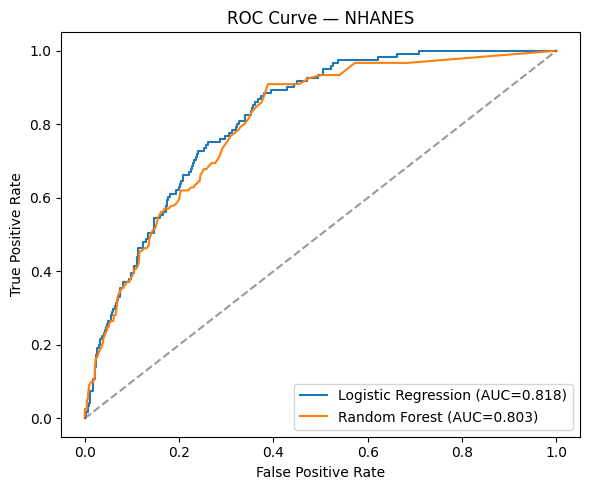

In [ ]:
# SECTION 4 — PREDICTIVE MODELING
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, roc_curve

def run_models(df, target, feature_cols, name):
    print("="*60)
    print(f"  {name}  (n={len(df)}, positives={df[target].sum()})")
    print("="*60)

    X, y = df[feature_cols].copy(), df[target]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
        'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
    }

    plt.figure(figsize=(6,5))
    for mname, model in models.items():
        if 'Logistic' in mname:
            model.fit(X_train_s, y_train)
            proba = model.predict_proba(X_test_s)[:,1]; pred = model.predict(X_test_s)
        else:
            model.fit(X_train, y_train)
            proba = model.predict_proba(X_test)[:,1];  pred = model.predict(X_test)

        auc = roc_auc_score(y_test, proba)
        print(f"\n--- {mname} ---")
        print(f"ROC-AUC: {auc:.3f}")
        print("Confusion matrix [[TN FP][FN TP]]:")
        print(confusion_matrix(y_test, pred))
        print(classification_report(y_test, pred, digits=3))

        fpr, tpr, _ = roc_curve(y_test, proba)
        plt.plot(fpr, tpr, label=f'{mname} (AUC={auc:.3f})')

    plt.plot([0,1],[0,1],'k--',alpha=0.4)
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {name}'); plt.legend(); plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'roc_{name.lower()}.png', dpi=150)
    plt.show()

pima_features   = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
                   'Insulin','BMI','DiabetesPedigreeFunction','Age']
nhanes_features = ['Age','BMI','Waist','SystolicBP','IncomeRatio']

run_models(pima,   'Outcome',  pima_features,   'PIMA')
run_models(nhanes, 'Diabetes', nhanes_features, 'NHANES')